# 01 · ข้อมูลที่ใช้

**โจทย์:** ทุกสิ้นวัน t ใช้ข้อมูลถึงวัน t ทำนาย **ระดับน้ำสูงสุดรายวันของ X.44 (หาดใหญ่ใน, กลางเมือง)** ในวัน t+1 … t+5

ข้อมูลที่ใช้มี 5 อย่าง (3 อย่างแรกสำหรับ LSTM, 2 อย่างหลังสำหรับแผนที่ความเสี่ยงรายโซนใน notebook 04)
| ข้อมูล | แหล่ง | ใช้ทำอะไร |
|---|---|---|
| ระดับน้ำรายชั่วโมง 6 สถานี + ระดับตลิ่ง | ThaiWater (สสน.) | input หลัก และ target (X.44) |
| ฝนรายชั่วโมงเฉลี่ยทั้งลุ่มน้ำ | ERA5 (Open-Meteo archive) | ฝนที่ตกแล้ว และฝนอนาคตตอนเทรน |
| พยากรณ์ฝนย้อนหลัง | GFS (Open-Meteo Previous Runs) | ฝนอนาคตตอนทดสอบ (เหมือนใช้งานจริง) |
| ขอบเขตน้ำท่วม 23 พ.ย. 2568 | Sentinel Asia / EOS-RS (ภาพเรดาร์ Sentinel-1) | label ของโมเดลความเสี่ยงรายจุด |
| ความสูงภูมิประเทศ 30 ม. | Copernicus DEM GLO-30 | ลักษณะภูมิประเทศ (ความสูง, HAND, ความชัน ฯลฯ) |

ไฟล์เก็บใน `data/raw/` — ถ้ามีไฟล์อยู่แล้วจะโหลดจากไฟล์ ไม่ดึงใหม่ (ดึงครั้งแรกใช้เวลานาน)

In [1]:
import datetime

import matplotlib.pyplot as plt
import pandas

from mojito import config, sources

plt.rcParams.update({
    "font.family": ["Noto Sans Thai", "DejaVu Sans"],
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

FORCE = False  # True = ดึงใหม่ทั้งหมด
TODAY = datetime.date.today()
RAW = config.RAW_DIR
RAW.mkdir(parents=True, exist_ok=True)
session = sources.make_session(cache=True)

STATIONS = list(config.BANK_LEVEL_M)  # 6 สถานีที่ใช้


def save_once(name, fetch):
    """Run `fetch` and save its DataFrame, unless the file already exists."""
    path = RAW / name
    if path.exists() and not FORCE:
        frame = pandas.read_parquet(path)
        print(f"skip  {name}: มีอยู่แล้ว {len(frame):,} แถว")
        return frame
    frame = fetch()
    frame.to_parquet(path, index=False)
    print(f"saved {name}: {len(frame):,} แถว")
    return frame

## 1 · สถานีวัดระดับน้ำและระดับตลิ่ง
แต่ละสถานีวัดระดับน้ำเป็น **ม.รทก.** (เมตรเหนือระดับน้ำทะเลปานกลาง) แต่ท้องคลองแต่ละจุดสูงไม่เท่ากัน
เช่น X.173A อยู่ต้นน้ำ ระดับปกติ ~10 ม. ส่วน X.44 กลางเมืองปกติ ~0.5 ม. → ตัวเลขดิบเทียบกันข้ามสถานีไม่ได้

ThaiWater ให้ **ระดับตลิ่งต่ำสุด (`min_bank`)** ของแต่ละสถานีมาด้วย จึงแปลงเป็น **ระยะจากตลิ่ง = ระดับน้ำ − ตลิ่ง**
(0 = น้ำเสมอตลิ่ง, บวก = ล้นตลิ่ง) ทำให้ทุกสถานีอ่านด้วยความหมายเดียวกัน

In [2]:
stations = save_once("stations.parquet", lambda: sources.thaiwater_stations(session))

bank = (
    stations[(stations["kind"] == "waterlevel") & stations["code"].isin(STATIONS)]
    .set_index("code").loc[STATIONS, ["name", "agency", "lat", "lon", "min_bank"]]
    .assign(BANK_LEVEL_M=pandas.Series(config.BANK_LEVEL_M))
)
assert (bank["min_bank"] == bank["BANK_LEVEL_M"]).all(), "ค่าตลิ่งใน config ไม่ตรงกับ ThaiWater"
bank.rename(columns={"name": "ชื่อ", "agency": "หน่วยงาน", "min_bank": "ตลิ่ง (ม.รทก.)"}).drop(columns="BANK_LEVEL_M")

skip  stations.parquet: มีอยู่แล้ว 81 แถว


,ชื่อ,หน่วยงาน,lat,lon,ตลิ่ง (ม.รทก.)
code,,,,,
X.44,บ้านหาดใหญ่ใน,RID,7.002180,100.456062,7.15
X.90,บ้านบางศาลา,RID,6.931240,100.439857,9.34
X.173A,บ้านม่วงก็อง,RID,6.796630,100.442337,16.13
X.174,บ้านคลองหวะ,RID,6.986370,100.481857,8.88
SLA007,บางกล่ำ,HII,7.079418,100.427880,1.59
SLA005,ปากรอ,HII,7.261514,100.424470,0.97


ลำดับจากต้นน้ำไปปลายน้ำ: **X.173A** (ต้นน้ำคลองอู่ตะเภา) → **X.90** (บางศาลา) → **X.174** (คลองหวะ, ไหลเข้าเมือง)
→ **X.44** (หาดใหญ่ใน, target) → **SLA007** (บางกล่ำ) → **SLA005** (ปากรอ, ทะเลสาบสงขลา)

## 2 · ระดับน้ำรายชั่วโมง
ไฟล์นี้เก็บ 9 สถานี (เว็บเดิมใช้ทั้งหมด) แต่ pipeline นี้ใช้แค่ 6 สถานีข้างบน

In [3]:
waterlevel = save_once(
    "waterlevel_tele.parquet",
    lambda: sources.thaiwater_waterlevel(session, config.WATERLEVEL_STATIONS, range(2012, TODAY.year + 1)),
)
waterlevel = waterlevel[waterlevel["station_code"].isin(STATIONS)]
waterlevel.groupby("station_code")["timestamp"].agg(["min", "max", "count"]).loc[STATIONS]

skip  waterlevel_tele.parquet: มีอยู่แล้ว 2,090,520 แถว


,min,max,count
station_code,,,
X.44,2012-11-30 06:00:00+07:00,2026-10-04 16:00:00+07:00,50547
X.90,2012-11-30 06:00:00+07:00,2026-10-04 16:00:00+07:00,50427
X.173A,2020-02-13 01:00:00+07:00,2026-10-04 16:00:00+07:00,50542
X.174,2020-02-13 01:00:00+07:00,2026-10-04 16:00:00+07:00,50433
SLA007,2012-09-06 12:50:00+07:00,2026-10-04 16:50:00+07:00,544611
SLA005,2013-08-05 21:00:00+07:00,2026-10-04 16:50:00+07:00,458269


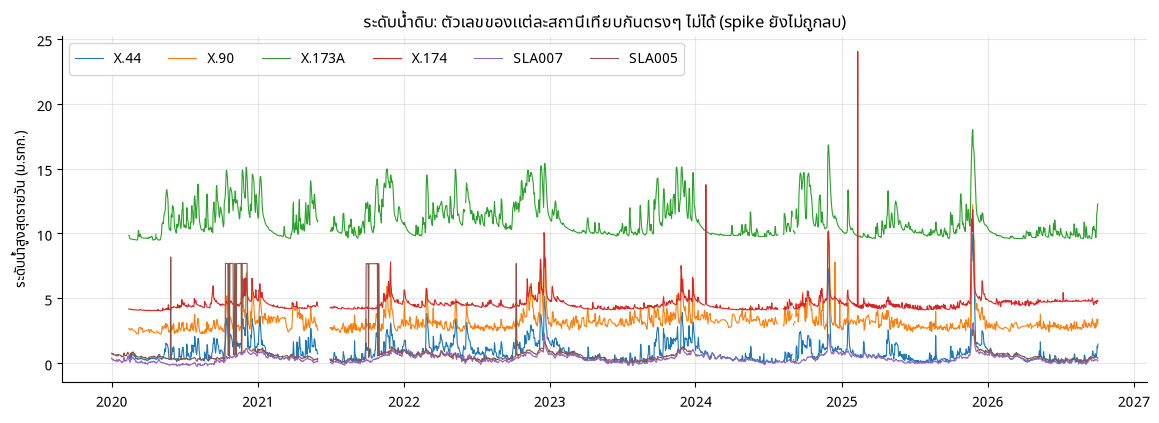

In [4]:
# ข้อมูลดิบ (ยังไม่ทำความสะอาด) ช่วง 2020 ขึ้นไป: แต่ละสถานีอยู่คนละระดับ
daily_raw = (
    waterlevel[waterlevel["waterlevel_msl"].abs() < 999]
    .set_index("timestamp").groupby("station_code")["waterlevel_msl"].resample("D").max()
    .unstack("station_code").loc["2020":, STATIONS]
)
fig, ax = plt.subplots(figsize=(14, 4.5))
for station in STATIONS:
    ax.plot(daily_raw.index, daily_raw[station], lw=0.8, label=station)
ax.set_ylabel("ระดับน้ำสูงสุดรายวัน (ม.รทก.)")
ax.set_title("ระดับน้ำดิบ: ตัวเลขของแต่ละสถานีเทียบกันตรงๆ ไม่ได้ (spike ยังไม่ถูกลบ)")
ax.legend(ncol=6, loc="upper left")
plt.show()

## 3 · ฝน ERA5 (ฝนที่ตกจริง)
ERA5 เป็นข้อมูล reanalysis รายชั่วโมง ใช้ 6 จุดกริด (0.25°) ที่คลุมลุ่มน้ำคลองอู่ตะเภา แล้วเฉลี่ยเป็นฝนทั้งลุ่มน้ำ
(ERA5 ช้ากว่าเวลาจริง ~5 วัน — ไม่เป็นปัญหาสำหรับการเทรนย้อนหลัง)

In [5]:
era5 = save_once(
    "era5_hourly.parquet",
    lambda: sources.era5_hourly(session, config.ERA5_POINTS, 1990, TODAY - datetime.timedelta(days=7)),
)
era5.groupby(["lat", "lon"])["timestamp"].agg(["min", "max", "count"])

skip  era5_hourly.parquet: มีอยู่แล้ว 1,932,336 แถว


min                       max   count
lat  lon                                                               
6.75 100.25 1990-01-01 00:00:00+07:00 2026-09-27 23:00:00+07:00  322056
     100.50 1990-01-01 00:00:00+07:00 2026-09-27 23:00:00+07:00  322056
7.00 100.25 1990-01-01 00:00:00+07:00 2026-09-27 23:00:00+07:00  322056
     100.50 1990-01-01 00:00:00+07:00 2026-09-27 23:00:00+07:00  322056
7.25 100.25 1990-01-01 00:00:00+07:00 2026-09-27 23:00:00+07:00  322056
     100.50 1990-01-01 00:00:00+07:00 2026-09-27 23:00:00+07:00  322056

## 4 · พยากรณ์ฝนย้อนหลัง (GFS)
ตอนใช้งานจริงเราไม่รู้ว่าพรุ่งนี้ฝนจะตกเท่าไร รู้แค่ **พยากรณ์** — Open-Meteo เก็บพยากรณ์ที่เคยออกในอดีตแยกตามจำนวนวันล่วงหน้า (lead)
ไว้ตั้งแต่ **มี.ค. 2024** จึงใช้ทดสอบได้ว่าโมเดลที่ป้อนพยากรณ์ฝน (ซึ่งผิดได้) ทำงานได้แค่ไหน
ไฟล์มีทั้ง ECMWF และ GFS; pipeline นี้ใช้ GFS

In [6]:
def fetch_previous_runs():
    return pandas.concat([
        sources.nwp_rain_previous_runs(session, config.ERA5_POINTS, model, sources.PREVIOUS_RUNS_START, TODAY)
        for model in ("ecmwf_ifs025", "gfs_seamless")
    ], ignore_index=True)


nwp_rain = save_once("nwp_rain_previous_runs.parquet", fetch_previous_runs)
gfs = nwp_rain[nwp_rain["model"] == "gfs_seamless"]
gfs.groupby("lead")["timestamp"].agg(["min", "max"])

skip  nwp_rain_previous_runs.parquet: มีอยู่แล้ว 1,637,370 แถว


,min,max
lead,,
1,2024-03-01 00:00:00+07:00,2026-10-04 23:00:00+07:00
2,2024-03-01 00:00:00+07:00,2026-10-04 23:00:00+07:00
3,2024-03-01 00:00:00+07:00,2026-10-04 23:00:00+07:00
4,2024-03-01 00:00:00+07:00,2026-10-04 23:00:00+07:00
5,2024-03-01 00:00:00+07:00,2026-10-04 23:00:00+07:00
6,2024-03-01 00:00:00+07:00,2026-10-04 23:00:00+07:00


## 5 · ข้อมูลเชิงพื้นที่: ขอบเขตน้ำท่วมจริงและความสูงภูมิประเทศ
ใช้ใน notebook 04 เพื่อแปลงระดับน้ำ X.44 ที่ทำนายได้เป็นแผนที่ความเสี่ยงรายโซน
- **EOS-RS** (Earth Observatory of Singapore ผ่าน Sentinel Asia): polygon น้ำท่วมจาก change detection ของภาพเรดาร์ Sentinel-1
  ก่อน/หลังน้ำท่วม (ภาพวันที่ 23 พ.ย. 2568) เห็นน้ำท่วมระหว่างอาคารในเมืองได้
- **Copernicus DEM GLO-30**: ความสูงภูมิประเทศช่องละ 30 × 30 ม. ครอบคลุมลุ่มน้ำ

In [7]:
EOSRS_PATH = RAW / "eosrs_flood_2025.parquet"
if EOSRS_PATH.exists() and not FORCE:
    print("skip  eosrs_flood_2025.parquet: มีอยู่แล้ว")
else:
    eosrs = sources.sentinel_asia_flood_proxy(session, config.BASIN_BBOX)
    eosrs.to_parquet(EOSRS_PATH)
    print(f"saved eosrs_flood_2025.parquet: {len(eosrs):,} polygon")

DEM_PATH = RAW / "dem_glo30.tif"
if DEM_PATH.exists() and not FORCE:
    print("skip  dem_glo30.tif: มีอยู่แล้ว")
else:
    dem = sources.copernicus_dem(DEM_PATH, config.BASIN_BBOX)
    print("saved dem_glo30.tif", dem.shape)

skip  eosrs_flood_2025.parquet: มีอยู่แล้ว
skip  dem_glo30.tif: มีอยู่แล้ว


**สรุป:** ข้อมูลพร้อมแล้วใน `data/raw/` → notebook 02 แปลงเป็นตารางรายวันและสร้าง input / target,
notebook 04 ใช้ขอบเขตน้ำท่วมและ DEM สร้างโซนความเสี่ยง